Set parameter Username
Academic license - for non-commercial use only - expires 2026-05-12
Solving model...
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (mac64[arm])

CPU model: Apple M1 Pro
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 3918 rows, 5910 columns and 7983 nonzeros
Model fingerprint: 0x64b67087
Variable types: 5910 continuous, 0 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 1e+04]

---------------------------------------------------------------------------
Multi-objectives: starting optimization with 4 objectives ... 
---------------------------------------------------------------------------

Multi-objectives: applying initial presolve ...
---------------------------------------------------------------------------

Presolve removed 3383 rows and 0 columns
Presolved: 535 rows and 5910 colum

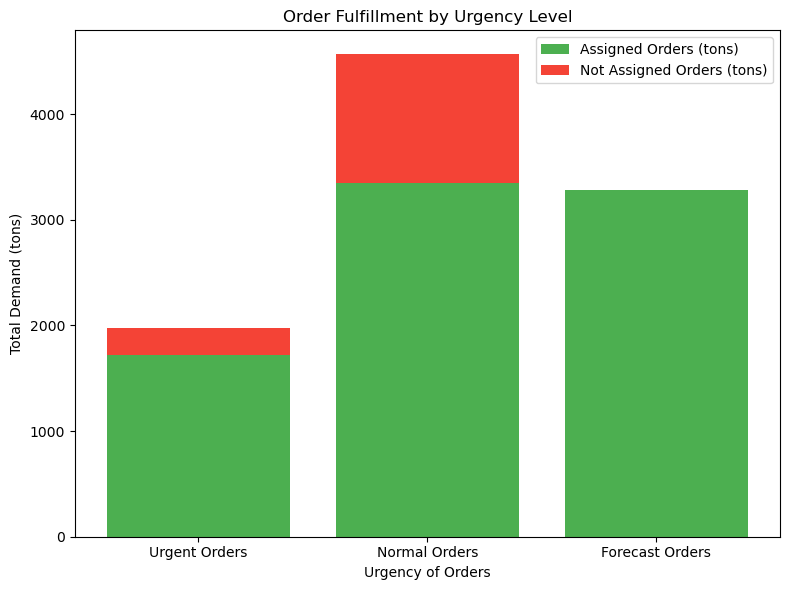

In [1]:
from gurobipy import Model, GRB, quicksum
from preprocess.preprocessModel import preprocessModel
import matplotlib.pyplot as plt
import numpy as np

def solve_fractional_assignment_with_urgency(setI, setJ, setU, setIJ, Hi, d_ju, partial = True):
    """
    Parameters:
    - setI: list of HRC types
    - setJ: list of orders
    - setU: list of urgency levels (e.g., [1, 2, 3])
    - setIJ: list of compatible (i,j) pairs
    - Hi: dict of available tons for each HRC i
    - d_ju: dict of demands for (j,u) keys → d_ju[(j,u)]
    """

    model = Model("Fractional_Assignment_MultiUrgency")

    # Variables
    x_iju = model.addVars(setIJ, setU, name="x_iju", lb=0.0)
    if partial:
        y_ju = model.addVars(setJ, setU, vtype=GRB.CONTINUOUS, name="y_ju")
    else:
        y_ju = model.addVars(setJ, setU, vtype=GRB.BINARY, name="y_ju")

    # Multi-objective: for each urgency level u, minimize sum of y_ju
    for priority, u in enumerate(sorted(setU), start=1):
        expr = quicksum(y_ju[j, u] for j in setJ)
        model.setObjectiveN(expr, index=u, priority=len(setU) - priority + 1, name=f"Urgency_{u}")
    #model.setObjectiveN(quicksum(y_ju[j, u] for j in setJ for u in setU), index=0, priority=1, name="All")

    # Constraint 1: Order fulfillment
    for j in setJ:
        for u in setU:
            assigned = quicksum(x_iju[i, j, u] for i in setI if (i, j) in setIJ)
            if partial:
                model.addConstr(assigned + y_ju[j, u] >= d_ju[j, u], name=f"fulfill_{j}_{u}")
            else:
                model.addConstr(assigned + y_ju[j, u] * d_ju[j, u] == d_ju[j, u], name=f"fulfill_{j}_{u}")

    # Constraint 2: HRC capacity
    for i in setI:
        total_usage = quicksum(x_iju[i, j, u] for j in setJ for u in setU if (i, j) in setIJ)
        model.addConstr(total_usage <= Hi[i], name=f"capacity_{i}")

    #write the model to txt file
    #model.write("results/assignmentModel.lp")
        
    # Solve model
    print("Solving model...")
    model.optimize()

    # Return solution
    if model.status == GRB.OPTIMAL:
        solution = {
            'x_iju': {(i, j, u): x_iju[i, j, u].X for i in setI for j in setJ for u in setU if (i, j) in setIJ},
            'y_ju': {(j, u): int(y_ju[j, u].X) for j in setJ for u in setU}
        }
        return solution
    else:
        return None
    

setI, setJ, setU, setIJ, H_i, dju, dictTanimI, dictTanimJ = preprocessModel()

setIeslenebilir = set()
for (i, j) in setIJ:
    if sum(dju[(j, u)] for u in [1,2]) > 0:
        setIeslenebilir.add(i)
            
setJdemanded = set()
for j in setJ:
    for u in [1, 2]:
        if dju[(j, u)] > 0:
            setJdemanded.add(j)

partial = True

solution = solve_fractional_assignment_with_urgency(setI, setJ, setU, setIJ, H_i, dju, partial)

#write the solution to excel
import pandas as pd

x_iju = solution['x_iju']
y_ju = solution['y_ju']

if partial:
    # Calculate demand meeting ratio for each urgency level
    demandMeetingRatio_u = [sum(dju[(j, u)] - y_ju[(j, u)] for j in setJ) / sum(dju[(j, u)] for j in setJ) for u in setU]
else:
    demandMeetingRatio_u = [sum(dju[(j, u)] for j in setJ if y_ju[j,u] == 0) / sum(dju[(j, u)] for j in setJ) for u in setU]

print(f"Demand Meeting Ratio u = 1: %{demandMeetingRatio_u[0] * 100}, u = 2: %{demandMeetingRatio_u[1] * 100}, u = 3: %{demandMeetingRatio_u[2] * 100}")

print(f"Hammadde kullanım oranı: {sum(x_iju[(i, j, u)] for (i, j) in setIJ for u in setU) / sum(H_i[i] for i in setI)}")

resultDF = pd.DataFrame(columns=["SpecGroupId", "Ürün tanımı", "Hammadde", "Hammadde Tanımı", "Talep (ton)", "Talep Aciliyeti", "Tahsis (ton)"])
row = 0
for (i, j, u), value in x_iju.items():
    if value > 1e-6:
        resultDF.at[row, "SpecGroupId"] = j
        resultDF.at[row, "Ürün tanımı"] = dictTanimJ[j]
        resultDF.at[row, "Hammadde"] = i
        resultDF.at[row, "Hammadde Tanımı"] = dictTanimI[i]
        resultDF.at[row, "Talep (ton)"] = dju[(j, u)]
        resultDF.at[row, "Talep Aciliyeti"] = "Acil" if u == 1 else "Normal" if u == 2 else "Tahmin"
        resultDF.at[row, "Tahsis (ton)"] = value
        row += 1
resultDF.to_excel("results/assignmentModel.xlsx", index=False)

ozetDF = pd.DataFrame(columns=["Aciliyet", "Talep (ton)", "Tahsis (ton)", "Tahsis Oranı"])
row = 0
for u in setU:
    totalDemand = sum(dju[(j, u)] for j in setJ)
    totalAllocation = sum(x_iju[(i, j, u)] for (i, j) in setIJ)
    allocationRatio = totalAllocation / totalDemand if totalDemand > 0 else ""
    ozetDF.at[row, "Aciliyet"] = "Acil" if u == 1 else "Normal" if u == 2 else "Tahmin"
    ozetDF.at[row, "Talep (ton)"] = totalDemand
    ozetDF.at[row, "Tahsis (ton)"] = totalAllocation
    ozetDF.at[row, "Tahsis Oranı"] = f"%{allocationRatio *100}"
    row += 1
ozetDF.at[row, "Aciliyet"] = "Hammadde kullanımı"
sumInv = sum(H_i[i] for i in setIeslenebilir)
sumAlloc = sum(x_iju[(i, j, u)] for (i, j) in setIJ for u in setU if i in setIeslenebilir)
ozetDF.at[row, "Talep (ton)"] = f"Toplam stok: {sumInv}"
ozetDF.at[row, "Tahsis (ton)"] = f"Toplam tahsis: {sumAlloc}"
ozetDF.at[row, "Tahsis Oranı"] = f"%{sumAlloc/sumInv * 100}"
    
ozetDF.to_excel("results/assignmentModelSummary.xlsx", index=False)

print("Results saved to results/assignmentModel.xlsx and results/assignmentModelSummary.xlsx")

hammaddeKullanımDF = pd.DataFrame(columns=["Hammadde", "Hammadde Tanımı", "Kullanım (ton)", "Stok (ton)", "Kullanım Oranı"])
row=0
for i in setI:
    hammaddeKullanımDF.at[row, "Hammadde"] = i
    hammaddeKullanımDF.at[row, "Hammadde Tanımı"] = dictTanimI[i]
    hammaddeKullanımDF.at[row, "Kullanım (ton)"] = sum(x_iju[(i, j, u)] for j in setJ for u in setU if (i, j) in setIJ)
    hammaddeKullanımDF.at[row, "Stok (ton)"] = H_i[i]
    hammaddeKullanımDF.at[row, "Kullanım Oranı"] = f"%{hammaddeKullanımDF.at[row, 'Kullanım (ton)'] / H_i[i] * 100}"
    row += 1
hammaddeKullanımDF.to_excel("results/hammaddeKullanım.xlsx", index=False)    


# Aciliyet bilgileri
urgency_labels = {1: "Urgent Orders", 2: "Normal Orders", 3: "Forecast Orders"}
urgency_colors = {'Met Demand': '#4CAF50', 'Unmet Demand': '#F44336'}  # Green and Red

# X ekseninde aciliyet seviyeleri
x = [urgency_labels[u] for u in setU]
x_indices = np.arange(len(setU))

# Y ekseninde tahsis ve karşılanamayan miktarlar
assigned_vals = []
unmet_vals = []

for u in setU:
    total_demand = sum(dju[(j, u)] for j in setJ)
    total_assigned = sum(x_iju[(i, j, u)] for (i, j) in setIJ)
    total_unmet = total_demand - total_assigned
    if u==3:
        total_unmet = 0

    assigned_vals.append(total_assigned)
    unmet_vals.append(total_unmet)

# Grafiği çiz
plt.figure(figsize=(8, 6))
plt.bar(x_indices, assigned_vals, color=urgency_colors['Met Demand'], label='Assigned Orders (tons)')
plt.bar(x_indices, unmet_vals, bottom=assigned_vals, color=urgency_colors['Unmet Demand'], label='Not Assigned Orders (tons)')

# Etiketler ve düzen
plt.xticks(x_indices, x)
plt.xlabel('Urgency of Orders')
plt.ylabel('Total Demand (tons)')
plt.title('Order Fulfillment by Urgency Level')
plt.legend()
plt.tight_layout()

# Kaydet ve göster
plt.savefig("results/aciliyet_barplot.png")
plt.show()



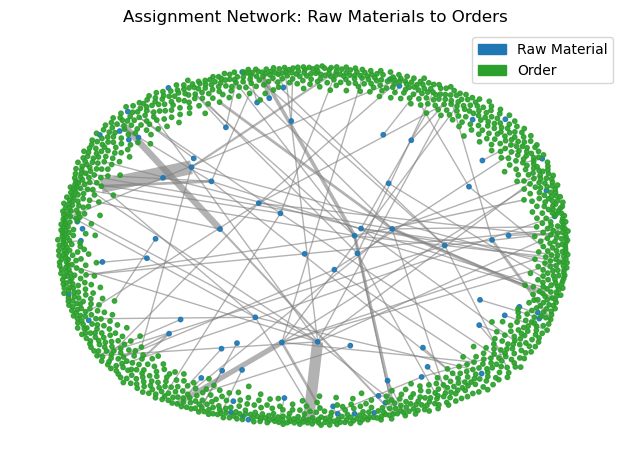

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Create graph
G = nx.DiGraph()

# Node types and colors
node_colors = {}
node_labels = {}

# Add nodes with types
for i in setI:
    node_id = f"RM-{i}"
    G.add_node(node_id)
    node_colors[node_id] = '#1f77b4'  # blue for raw material
    node_labels[node_id] = dictTanimI[i]

for j in setJ:
    node_id = f"ORD-{j}"
    G.add_node(node_id)
    node_colors[node_id] = '#2ca02c'  # green for order
    node_labels[node_id] = dictTanimJ[j]

# Add summed edges (i,j)
assignment_sum = defaultdict(float)
for (i, j, u), val in x_iju.items():
    if val > 1e-6:
        assignment_sum[(i, j)] += val

for (i, j), val in assignment_sum.items():
    G.add_edge(f"RM-{i}", f"ORD-{j}", weight=val)
    #print(val)

# Graph layout
pos = nx.spring_layout(G, k=0.2, iterations=50, seed=42)  # "spring force" layout

# Draw nodes with color by type
node_color_list = [node_colors[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=10, node_color=node_color_list, alpha=0.9)

# Draw edges with width proportional to tons assigned
edges = G.edges(data=True)

edge_widths = [max(10, d['weight'] / 10)/10 for (_, _, d) in edges]
#no arrows
nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_widths, edge_color='gray', alpha=0.6, arrows=False)
#nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_widths, edge_color='gray', alpha=0.6)

# Optional: draw node labels
#nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7)

# Legend
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#1f77b4', label='Raw Material'),
    mpatches.Patch(color='#2ca02c', label='Order'),
]
plt.legend(handles=legend_handles, loc='best')

# Finalize
plt.title("Assignment Network: Raw Materials to Orders")
plt.axis('off')
plt.tight_layout()
plt.savefig("results/assignment_network_force_layout.png")
plt.show()
